# Explore LandSat satellite remote sensing data with R.
tutorial reference: https://rspatial.org/rs/2-exploration.html

In [1]:
install.packages("terra")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [3]:
dir.create("data", showWarnings = FALSE)
if (!file.exists("data/rs/samples.rds")) {
    download.file("https://geodata.ucdavis.edu/rspatial/rs.zip", dest = "data/rs.zip")
    unzip("data/rs.zip", exdir="data")
}

In [11]:
# Create SpatRaster objects for single Landsat layers (bands)
library(terra)
## terra 1.9.21
# Blue
b2 <- rast('data/rs/LC08_044034_20170614_B2.tif')
b2

class       : SpatRaster
size        : 1245, 1497, 1  (nrow, ncol, nlyr)
resolution  : 30, 30  (x, y)
extent      : 594090, 639000, 4190190, 4227540  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 10N (EPSG:32610)
source      : LC08_044034_20170614_B2.tif
name        : LC08_044034_20170614_B2
min value   :                 0.07484
max value   :                0.717756

In [12]:
# Green
b3 <- rast('data/rs/LC08_044034_20170614_B3.tif')
b3

class       : SpatRaster
size        : 1245, 1497, 1  (nrow, ncol, nlyr)
resolution  : 30, 30  (x, y)
extent      : 594090, 639000, 4190190, 4227540  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 10N (EPSG:32610)
source      : LC08_044034_20170614_B3.tif
name        : LC08_044034_20170614_B3
min value   :                0.042592
max value   :                 0.69247

In [13]:
# Red
b4 <- rast('data/rs/LC08_044034_20170614_B4.tif')
b4

class       : SpatRaster
size        : 1245, 1497, 1  (nrow, ncol, nlyr)
resolution  : 30, 30  (x, y)
extent      : 594090, 639000, 4190190, 4227540  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 10N (EPSG:32610)
source      : LC08_044034_20170614_B4.tif
name        : LC08_044034_20170614_B4
min value   :                0.020841
max value   :                0.786177

In [14]:
# Near Infrared (NIR)
b5 <- rast('data/rs/LC08_044034_20170614_B5.tif')
b5

class       : SpatRaster
size        : 1245, 1497, 1  (nrow, ncol, nlyr)
resolution  : 30, 30  (x, y)
extent      : 594090, 639000, 4190190, 4227540  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 10N (EPSG:32610)
source      : LC08_044034_20170614_B5.tif
name        : LC08_044034_20170614_B5
min value   :                0.000846
max value   :                1.012432

### Image information and statistics
```
# coordinate reference system (CRS)
crs(b2)
## [1] "PROJCRS[\"WGS 84 / UTM zone 10N\",\n    BASEGEOGCRS[\"WGS 84\",\n        DATUM[\"World Geodetic System 1984\",\n            ELLIPSOID[\"WGS 84\",6378137,298.257223563,\n                LENGTHUNIT[\"metre\",1]]],\n        PRIMEM[\"Greenwich\",0,\n            ANGLEUNIT[\"degree\",0.0174532925199433]],\n        ID[\"EPSG\",4326]],\n    CONVERSION[\"UTM zone 10N\",\n        METHOD[\"Transverse Mercator\",\n            ID[\"EPSG\",9807]],\n        PARAMETER[\"Latitude of natural origin\",0,\n            ANGLEUNIT[\"degree\",0.0174532925199433],\n            ID[\"EPSG\",8801]],\n        PARAMETER[\"Longitude of natural origin\",-123,\n            ANGLEUNIT[\"degree\",0.0174532925199433],\n            ID[\"EPSG\",8802]],\n        PARAMETER[\"Scale factor at natural origin\",0.9996,\n            SCALEUNIT[\"unity\",1],\n            ID[\"EPSG\",8805]],\n        PARAMETER[\"False easting\",500000,\n            LENGTHUNIT[\"metre\",1],\n            ID[\"EPSG\",8806]],\n        PARAMETER[\"False northing\",0,\n            LENGTHUNIT[\"metre\",1],\n            ID[\"EPSG\",8807]]],\n    CS[Cartesian,2],\n        AXIS[\"(E)\",east,\n            ORDER[1],\n            LENGTHUNIT[\"metre\",1]],\n        AXIS[\"(N)\",north,\n            ORDER[2],\n            LENGTHUNIT[\"metre\",1]],\n    USAGE[\n        SCOPE[\"Navigation and medium accuracy spatial referencing.\"],\n        AREA[\"Between 126°W and 120°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - British Columbia (BC); Northwest Territories (NWT); Nunavut; Yukon. United States (USA) - Alaska (AK).\"],\n        BBOX[0,-126,84,-120]],\n    ID[\"EPSG\",32610]]"
# Number of cells, rows, columns
ncell(b2)
## [1] 1863765
dim(b2)
## [1] 1245 1497    1
# spatial resolution
res(b2)
## [1] 30 30
# Number of layers (bands in remote sensing jargon)
nlyr(b2)
## [1] 1
# Do the bands have the same extent, number of rows and columns, projection, resolution, and origin
compareGeom(b2,b3)
## [1] TRUE
```

In [15]:
print(crs(b2))
print(ncell(b2))
print(dim(b2))
print(res(b2))
print(nlyr(b2))
compareGeom(b2,b3)

[1] "PROJCRS[\"WGS 84 / UTM zone 10N\",\n    BASEGEOGCRS[\"WGS 84\",\n        DATUM[\"World Geodetic System 1984\",\n            ELLIPSOID[\"WGS 84\",6378137,298.257223563,\n                LENGTHUNIT[\"metre\",1]]],\n        PRIMEM[\"Greenwich\",0,\n            ANGLEUNIT[\"degree\",0.0174532925199433]],\n        ID[\"EPSG\",4326]],\n    CONVERSION[\"UTM zone 10N\",\n        METHOD[\"Transverse Mercator\",\n            ID[\"EPSG\",9807]],\n        PARAMETER[\"Latitude of natural origin\",0,\n            ANGLEUNIT[\"degree\",0.0174532925199433],\n            ID[\"EPSG\",8801]],\n        PARAMETER[\"Longitude of natural origin\",-123,\n            ANGLEUNIT[\"degree\",0.0174532925199433],\n            ID[\"EPSG\",8802]],\n        PARAMETER[\"Scale factor at natural origin\",0.9996,\n            SCALEUNIT[\"unity\",1],\n            ID[\"EPSG\",8805]],\n        PARAMETER[\"False easting\",500000,\n            LENGTHUNIT[\"metre\",1],\n            ID[\"EPSG\",8806]],\n        PARAMETER[\"Fa

[1] TRUE

In [5]:
# You can create a SpatRaster with multiple layers from the existing SpatRaster (single layer) objects.
s <- c(b5, b4, b3)
print(s)

# can also create the multi-layer SpatRaster using the filenames.
filenames <- paste0('data/rs/LC08_044034_20170614_B', 1:11, ".tif")
print(filenames)

class       : SpatRaster
size        : 1245, 1497, 3  (nrow, ncol, nlyr)
resolution  : 30, 30  (x, y)
extent      : 594090, 639000, 4190190, 4227540  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 10N (EPSG:32610)
sources     : LC08_044034_20170614_B5.tif
              LC08_044034_20170614_B4.tif
              LC08_044034_20170614_B3.tif
names       : LC08_04403~0170614_B5, LC08_04403~0170614_B4, LC08_04403~0170614_B3
min values  :              0.000846,              0.020841,              0.042592
max values  :              1.012432,              0.786177,               0.69247
 [1] "data/rs/LC08_044034_20170614_B1.tif" 
 [2] "data/rs/LC08_044034_20170614_B2.tif" 
 [3] "data/rs/LC08_044034_20170614_B3.tif" 
 [4] "data/rs/LC08_044034_20170614_B4.tif" 
 [5] "data/rs/LC08_044034_20170614_B5.tif" 
 [6] "data/rs/LC08_044034_20170614_B6.tif" 
 [7] "data/rs/LC08_044034_20170614_B7.tif" 
 [8] "data/rs/LC08_044034_20170614_B8.tif" 
 [9] "data/rs/LC08_044034_20170614_B9.tif" 
[10] "da

In [16]:
landsat <- rast(filenames)
landsat

class       : SpatRaster
size        : 1245, 1497, 11  (nrow, ncol, nlyr)
resolution  : 30, 30  (x, y)
extent      : 594090, 639000, 4190190, 4227540  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 10N (EPSG:32610)
sources     : LC08_044034_20170614_B1.tif
              LC08_044034_20170614_B2.tif
              LC08_044034_20170614_B3.tif
              ... and 8 more sources
names       : LC08_~14_B1, LC08_~14_B2, LC08_~14_B3, LC08_~14_B4, LC08_~14_B5, LC08_~14_B6, ...
min values  :    0.096418,     0.07484,    0.042592,    0.020841,    0.000846,   -0.007872, ...
max values  :    0.734628,    0.717756,     0.69247,    0.786177,    1.012432,    1.043205, ...

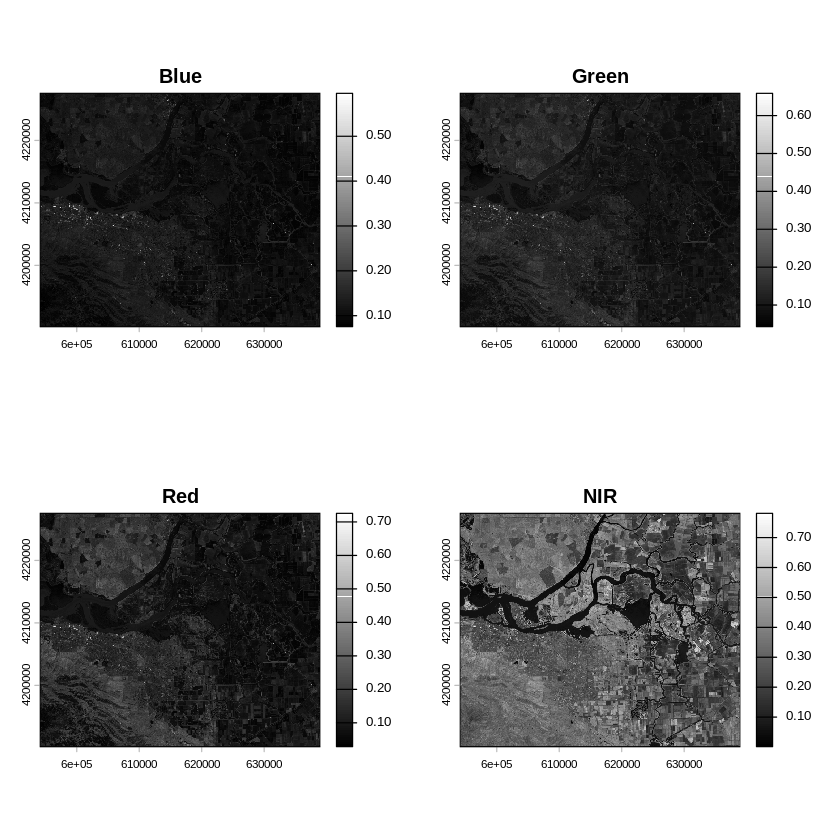

In [6]:
# plot individual layers of a multi-spectral image - panel plot
par(mfrow = c(2,2))
plot(b2, main = "Blue", col = gray(0:100 / 100))
plot(b3, main = "Green", col = gray(0:100 / 100))
plot(b4, main = "Red", col = gray(0:100 / 100))
plot(b5, main = "NIR", col = gray(0:100 / 100))


The legends of the maps created above can range between 0 and 1. Notice the difference in shading and range of legends between the different bands. This is because different surface features reflect the incident solar radiation differently. Each layer represent how much incident solar radiation is reflected for a particular wavelength range. For example, vegetation reflects more energy in NIR than other wavelengths and thus appears brighter. In contrast, water absorbs most of the energy in the NIR wavelength and it appears dark.

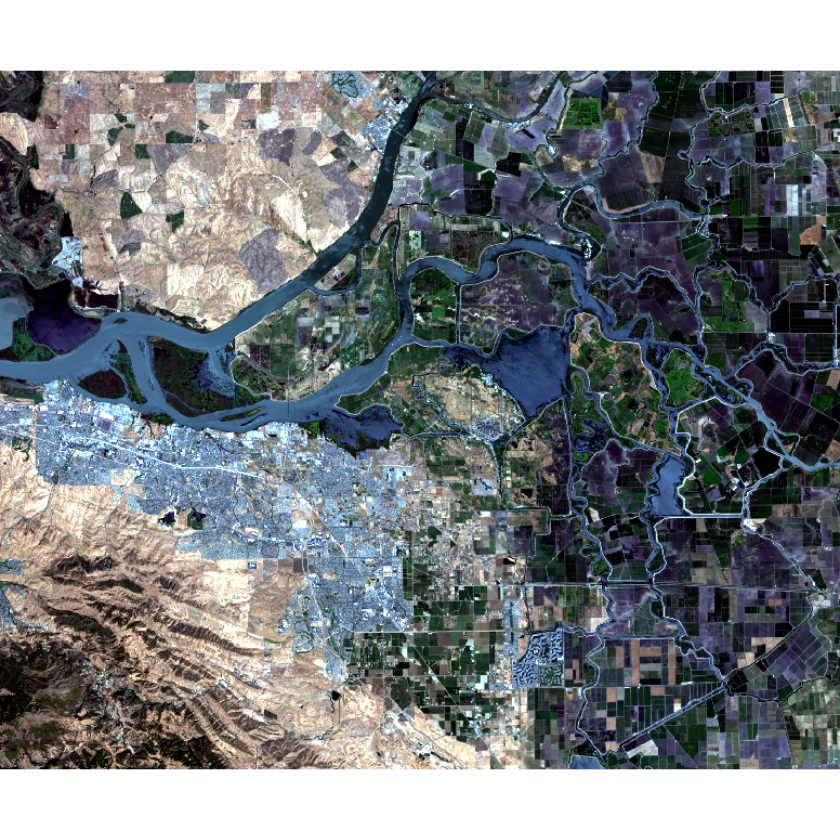

In [7]:
# “true (or natural) color” image: red, green and blue regions:  band 4 (red), 3 (green), and 2 (blue)
landsatRGB <- c(b4, b3, b2)
plotRGB(landsatRGB, stretch = "lin")
#  Note that use of strecth = "lin" (otherwise the image will be pitch-dark).

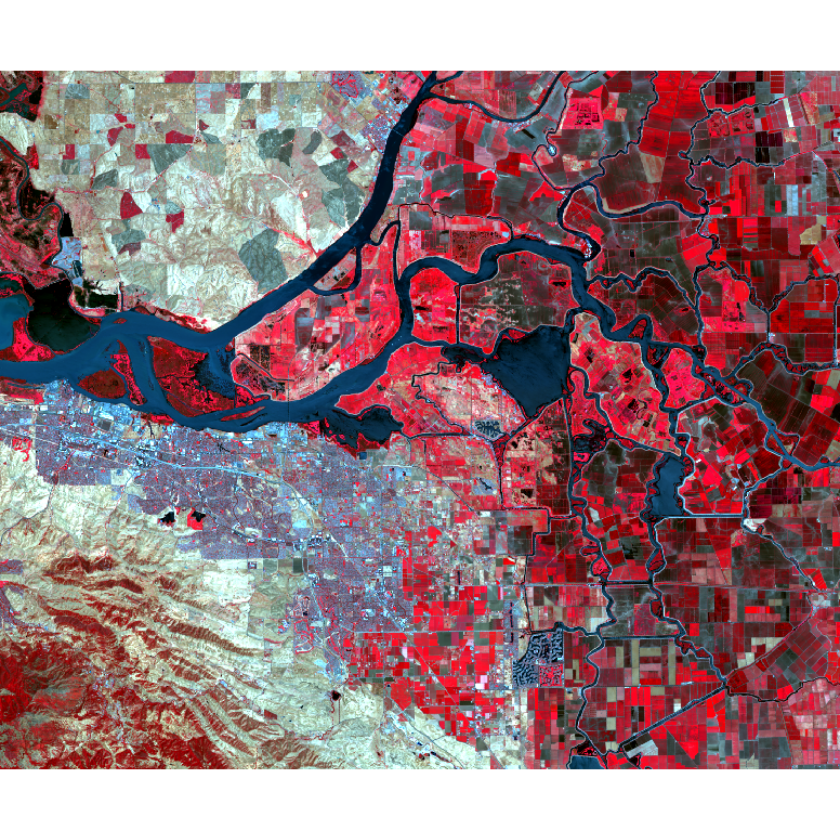

In [8]:
#  “false color” image in which NIR, red, and green bands are combined.
# This representation is popular as it makes it easy to see the vegetation (in red).
landsatFCC <- c(b5, b4, b3)
plotRGB(landsatFCC, stretch="lin")

In [17]:
# can select specific layers (bands) using subset function, or via indexing

# select first 3 bands only
landsatsub1 <- subset(landsat, 1:3)

# alternative way
landsatsub2 <- landsat[[1:3]]

# Number of bands in the original and new data
print(nlyr(landsat))

print(nlyr(landsatsub1))

print(nlyr(landsatsub2))


[1] 11
[1] 3
[1] 3


In [18]:
# select first 7 bands
landsat <- subset(landsat, 1:7)
names(landsat)

[1] "LC08_044034_20170614_B1" "LC08_044034_20170614_B2"
[3] "LC08_044034_20170614_B3" "LC08_044034_20170614_B4"
[5] "LC08_044034_20170614_B5" "LC08_044034_20170614_B6"
[7] "LC08_044034_20170614_B7"

In [19]:
# can name these bands
names(landsat) <- c('ultra-blue', 'blue', 'green', 'red', 'NIR', 'SWIR1', 'SWIR2')
names(landsat)

[1] "ultra-blue" "blue"       "green"      "red"        "NIR"       
[6] "SWIR1"      "SWIR2"

In [20]:
# Spatial subsetting can be used to limit analysis to a geographic subset of the image.
# Spatial subsets can be created with the crop function, using a SpatExtent object,
# or another spatial object from which an Extent can be extracted.
ext(landsat)

SpatExtent : 594090, 639000, 4190190, 4227540 (xmin, xmax, ymin, ymax)

In [25]:
# select extent
e <- ext(624387, 635752, 4200047, 4210939)

# crop landsat by the extent
landsatcrop <- crop(landsat, e)

In [23]:
# can save the results
writeRaster(landsatcrop, filename="cropped-landsat.tif", overwrite=TRUE)

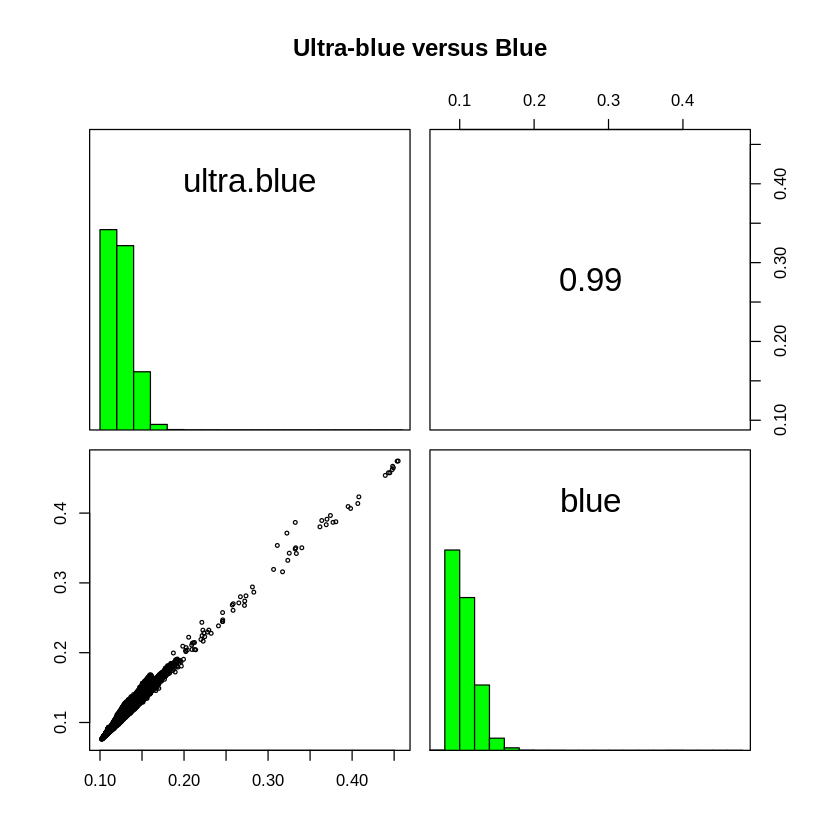

In [26]:
# explor relationships between raster layers
# A plot of reflection in the ultra-blue wavelength against reflection in the blue wavelength.

pairs(landsatcrop[[1:2]], main = "Ultra-blue versus Blue")

The above plot reveals high correlations between the blue wavelength regions. Because of the high correlation, we can just use one of the blue bands without losing much information.

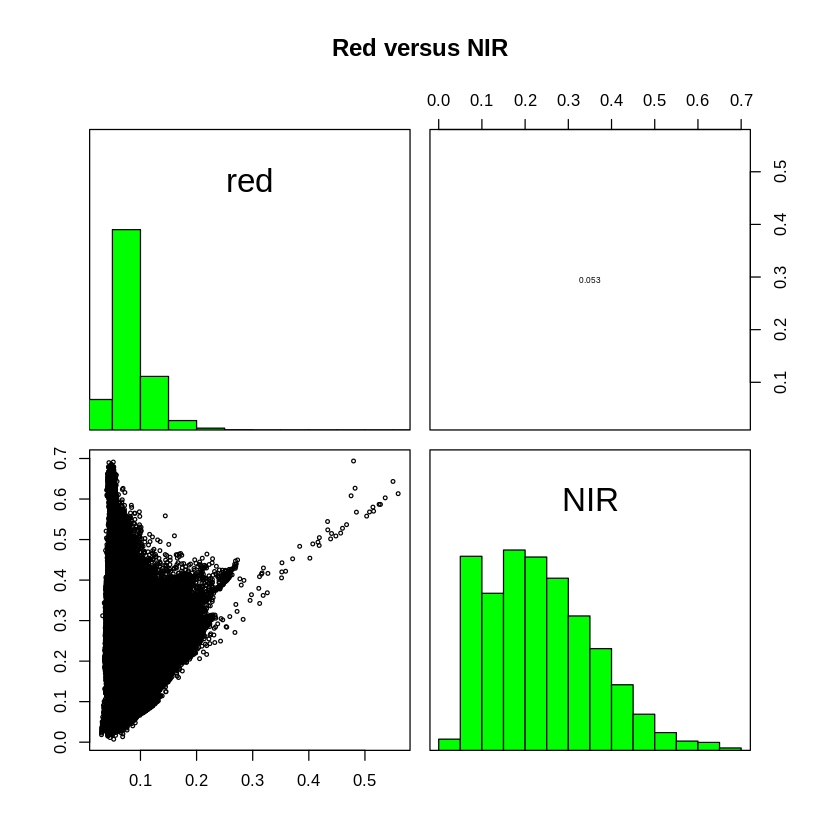

In [27]:
# A plot of reflection in the red wavelength against reflection in the NIR wavelength.

pairs(landsatcrop[[4:5]], main = "Red versus NIR")

The distribution of points in above plot (between NIR and red) is unique due to its triangular shape. Vegetation reflects very highly in the NIR range than red and creates the upper corner close to NIR (y) axis. Water absorbs energy from all the bands and occupies the location close to origin. The furthest corner is created due to highly reflecting surface features like bright soil or concrete

In [28]:
# Extract cell values
# load the polygons with land use land cover information
samp <- readRDS('data/rs/lcsamples.rds')
# generate 50 point samples from the polygons
set.seed(555)
ptsamp <- spatSample(samp, 50, 'regular')
# We use the x-y coordinates to extract the spectral values for the locations
df <- extract(landsat, ptsamp)
# To see some of the reflectance values
head(df)

,ID,ultra-blue,blue,green,red,NIR,SWIR1,SWIR2
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,0.1154152,0.09286134,0.08362291,0.05464983,0.43908536,0.16941448,0.08999872
2,2,0.1109912,0.08893609,0.08464217,0.05553897,0.38280904,0.09902029,0.04517285
3,3,0.1083455,0.08470724,0.07037250,0.04621380,0.33631334,0.16342902,0.07896033
4,4,0.1132900,0.09097461,0.08505422,0.05432453,0.45357192,0.20305014,0.08722286
5,5,0.1414823,0.12404644,0.10318408,0.08483735,0.06360633,0.04842582,0.03894885
6,6,0.1240898,0.10487562,0.07991453,0.05924735,0.03840668,0.01986478,0.01570098


### Spectral profiles
A plot of the spectrum (all bands) for pixels representing a certain earth surface features (e.g. water) is known as a spectral profile. Such profiles demonstrate the differences in spectral properties of various earth surface features and constitute the basis for image analysis. Spectral values can be extracted from any multispectral data set using extract function. In the above example, we extracted values of Landsat data for the samples. These samples include: cropland, water, fallow, built and open. First we compute the mean reflectance values for each class and each band.

In [29]:
ms <- aggregate(df[,-1], list(ptsamp$class), mean)
# instead of the first column, we use row names
rownames(ms) <- ms[,1]
ms <- ms[,-1]
ms

,ultra-blue,blue,green,red,NIR,SWIR1,SWIR2
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
built,0.1786493,0.16950844,0.17206383,0.18493112,0.22927266,0.2335666,0.19642493
cropland,0.1120105,0.08936982,0.08092295,0.05268178,0.40294491,0.1587285,0.07533869
fallow,0.1304385,0.11181529,0.09206436,0.09047041,0.12907769,0.2044923,0.19113344
open,0.1390433,0.13788239,0.15237471,0.20631468,0.34316624,0.3646445,0.21842583
water,0.1327735,0.11559101,0.09775448,0.07715008,0.04756178,0.0319213,0.02590160


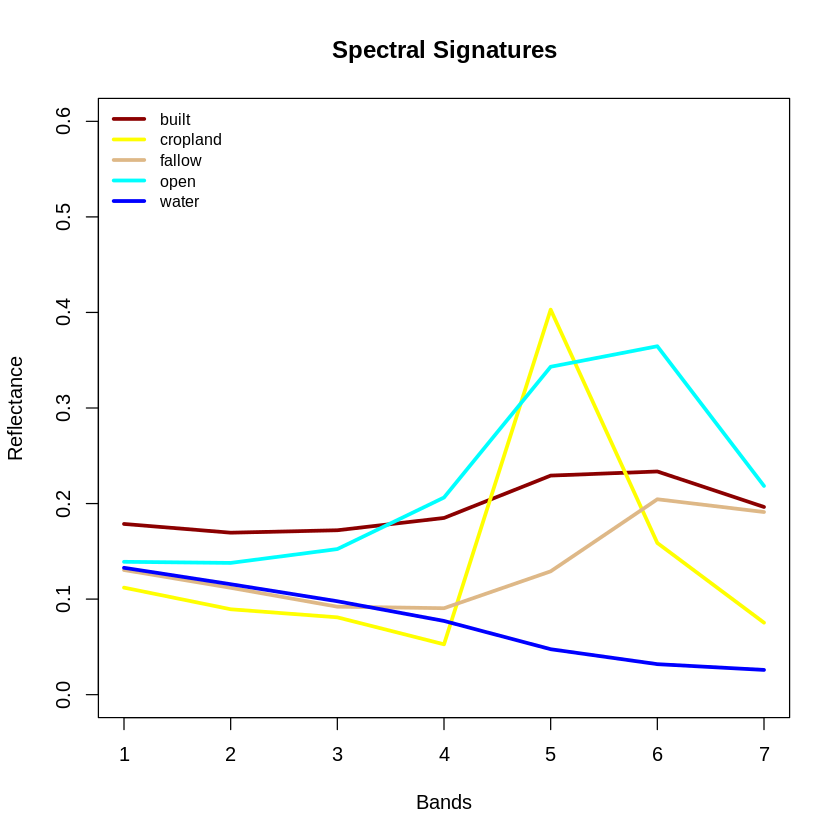

In [30]:
# plot the mean spectra of these features.

# Create a vector of color for the land cover classes for use in plotting
mycolor <- c('darkred', 'yellow', 'burlywood', 'cyan', 'blue')
#transform ms from a data.frame to a matrix
ms <- as.matrix(ms)
# First create an empty plot
plot(0, ylim=c(0,0.6), xlim = c(1,7), type='n', xlab="Bands", ylab = "Reflectance")
# add the different classes
for (i in 1:nrow(ms)){
  lines(ms[i,], type = "l", lwd = 3, lty = 1, col = mycolor[i])
}
# Title
title(main="Spectral Signatures", font.main = 2)
# Legend
legend("topleft", rownames(ms),
       cex=0.8, col=mycolor, lty = 1, lwd =3, bty = "n")

The spectral signatures (profile) shows (dis)similarity in the reflectance of different features on the earth’s surface (or above it). ‘Water’ shows relatively low reflection in all wavelengths, and ‘built’, ‘fallow’ and ‘open’ have relatively high reflectance in the longer wavelengts.